# Filtering and Normalization of Smart-seq2 fly neuron

### Purpose
Quality control, filtering, and normalization pipeline for Smart-seq2 single-cell RNA-seq data from Drosophila projection neurons at 12h APF developmental stage. This workflow processes 384-well plates through rigorous QC filtering to retain high-quality neuronal cells.

### Multi-stage filtering
ERCC spike-in outliers → basic QC (counts & mitochondrial%) → neuronal marker expression

### Software Requirements
```
Python:      3.10.11
scanpy:      1.11.4
pandas:      2.3.2
numpy:       2.2.6
matplotlib:  3.10.6
seaborn:     0.13.2
```

---

## Setup and Imports

In [40]:
# Standard library imports
from pathlib import Path
import os
import sys
import warnings

# Third-party imports
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

# AnnData specific
from anndata._core.aligned_df import ImplicitModificationWarning

# Configure scanpy
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

# Suppress warnings
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)
warnings.filterwarnings('ignore', message='invalid value encountered in det')
warnings.filterwarnings('ignore', message='invalid value encountered in divide')  
warnings.filterwarnings('ignore', category=RuntimeWarning)  

---

## Configuration

Update these paths to match your data files

In [36]:
# File paths for your 6 (or 7) plates
file_paths = [
    'Plate1_count_table.csv',
    'Plate2_count_table.csv',
    'Plate3_count_table.csv',
    'Plate4_count_table.csv',
    'Plate5_count_table.csv',
    'Plate6_count_table.csv',
    'Plate7_count_table.csv'
]

plate_names = ['plate1', 'plate2', 'plate3', 'plate4', 'plate5', 'plate6', 'plate7']

# Filtering parameters (FROM YOUR COLLEAGUE'S WORKFLOW)
min_counts = 100000  # Very high! Smart-seq2 data
max_pct_mt = 5       # Strict mitochondrial threshold

# Current working directory (usable in Jupyter / VSCode interactive)
current_dir = Path(os.getcwd())
output_dir = current_dir / "qc_plots"
output_dir.mkdir(parents=True, exist_ok=True)

# print(f"QC plots will be saved to: {output_dir.resolve()}")

---

## Step 1: Load Data, Filter ERCC outliers, and Remove ERCC



In [37]:
# Read data
df = pd.read_csv('Plate1_count_table.csv', index_col=0)

# Check ERCC (handle NaN)
# Method 1: use fillna to set NaN to False
ercc_mask = df.index.str.startswith('ERCC-', na=False)
ercc_genes = df.index[ercc_mask]

print(f"Found {len(ercc_genes)}  ERCC genes")

if len(ercc_genes) > 0:
    print("\nYour data contains ERCC spike-ins")
    print(f"\nERCC example:")
    print(ercc_genes[:5].tolist())
else:
    print("No ERCC found")

Found 96  ERCC genes

Your data contains ERCC spike-ins

ERCC example:
['ERCC-00002', 'ERCC-00003', 'ERCC-00004', 'ERCC-00007', 'ERCC-00009']


In [38]:
def load_data_with_ercc(file_path, plate_name):

    print(f"\nLoading {plate_name} from {file_path}...")
    
    # read CSV
    df = pd.read_csv(file_path, index_col=0)
   
    # create AnnData and transpose
    adata = sc.AnnData(df.T)
    
    # add metadata
    adata.obs['plate'] = plate_name
    adata.obs['stage'] = '12h'

    # ERCC
    adata.var['ercc'] = adata.var_names.str.startswith('ERCC', na=False)
    n_ercc = adata.var['ercc'].sum()
    
    return adata

adatas_with_ercc = []

for file_path, plate_name in zip(file_paths, plate_names):
    try:
        adata = load_data_with_ercc(file_path, plate_name)
        adatas_with_ercc.append(adata)
    except FileNotFoundError:
        print(f"⚠️ file not found, skip: {file_path}")

print(f"\n✅ loaded {len(adatas_with_ercc)} plates")


Loading plate1 from Plate1_count_table.csv...

Loading plate2 from Plate2_count_table.csv...

Loading plate3 from Plate3_count_table.csv...

Loading plate4 from Plate4_count_table.csv...

Loading plate5 from Plate5_count_table.csv...

Loading plate6 from Plate6_count_table.csv...

Loading plate7 from Plate7_count_table.csv...

✅ loaded 7 plates



Merging 7 plates (before filtering)...
Merging 7 plates (after filtering)...

📊 CELL COUNT SUMMARY (Filter Before vs After)
Plate                Before       After        Removed      % Removed   
--------------------------------------------------------------------------------
plate1               384          376          8            2.08        
plate2               384          375          9            2.34        
plate3               384          354          30           7.81        
plate4               384          369          15           3.91        
plate5               384          373          11           2.86        
plate6               384          370          14           3.65        
plate7               384          345          39           10.16       
--------------------------------------------------------------------------------
TOTAL                2688         2562         126          4.69        

Generating ERCC% distribution plots...

💾 Saved: qc_res

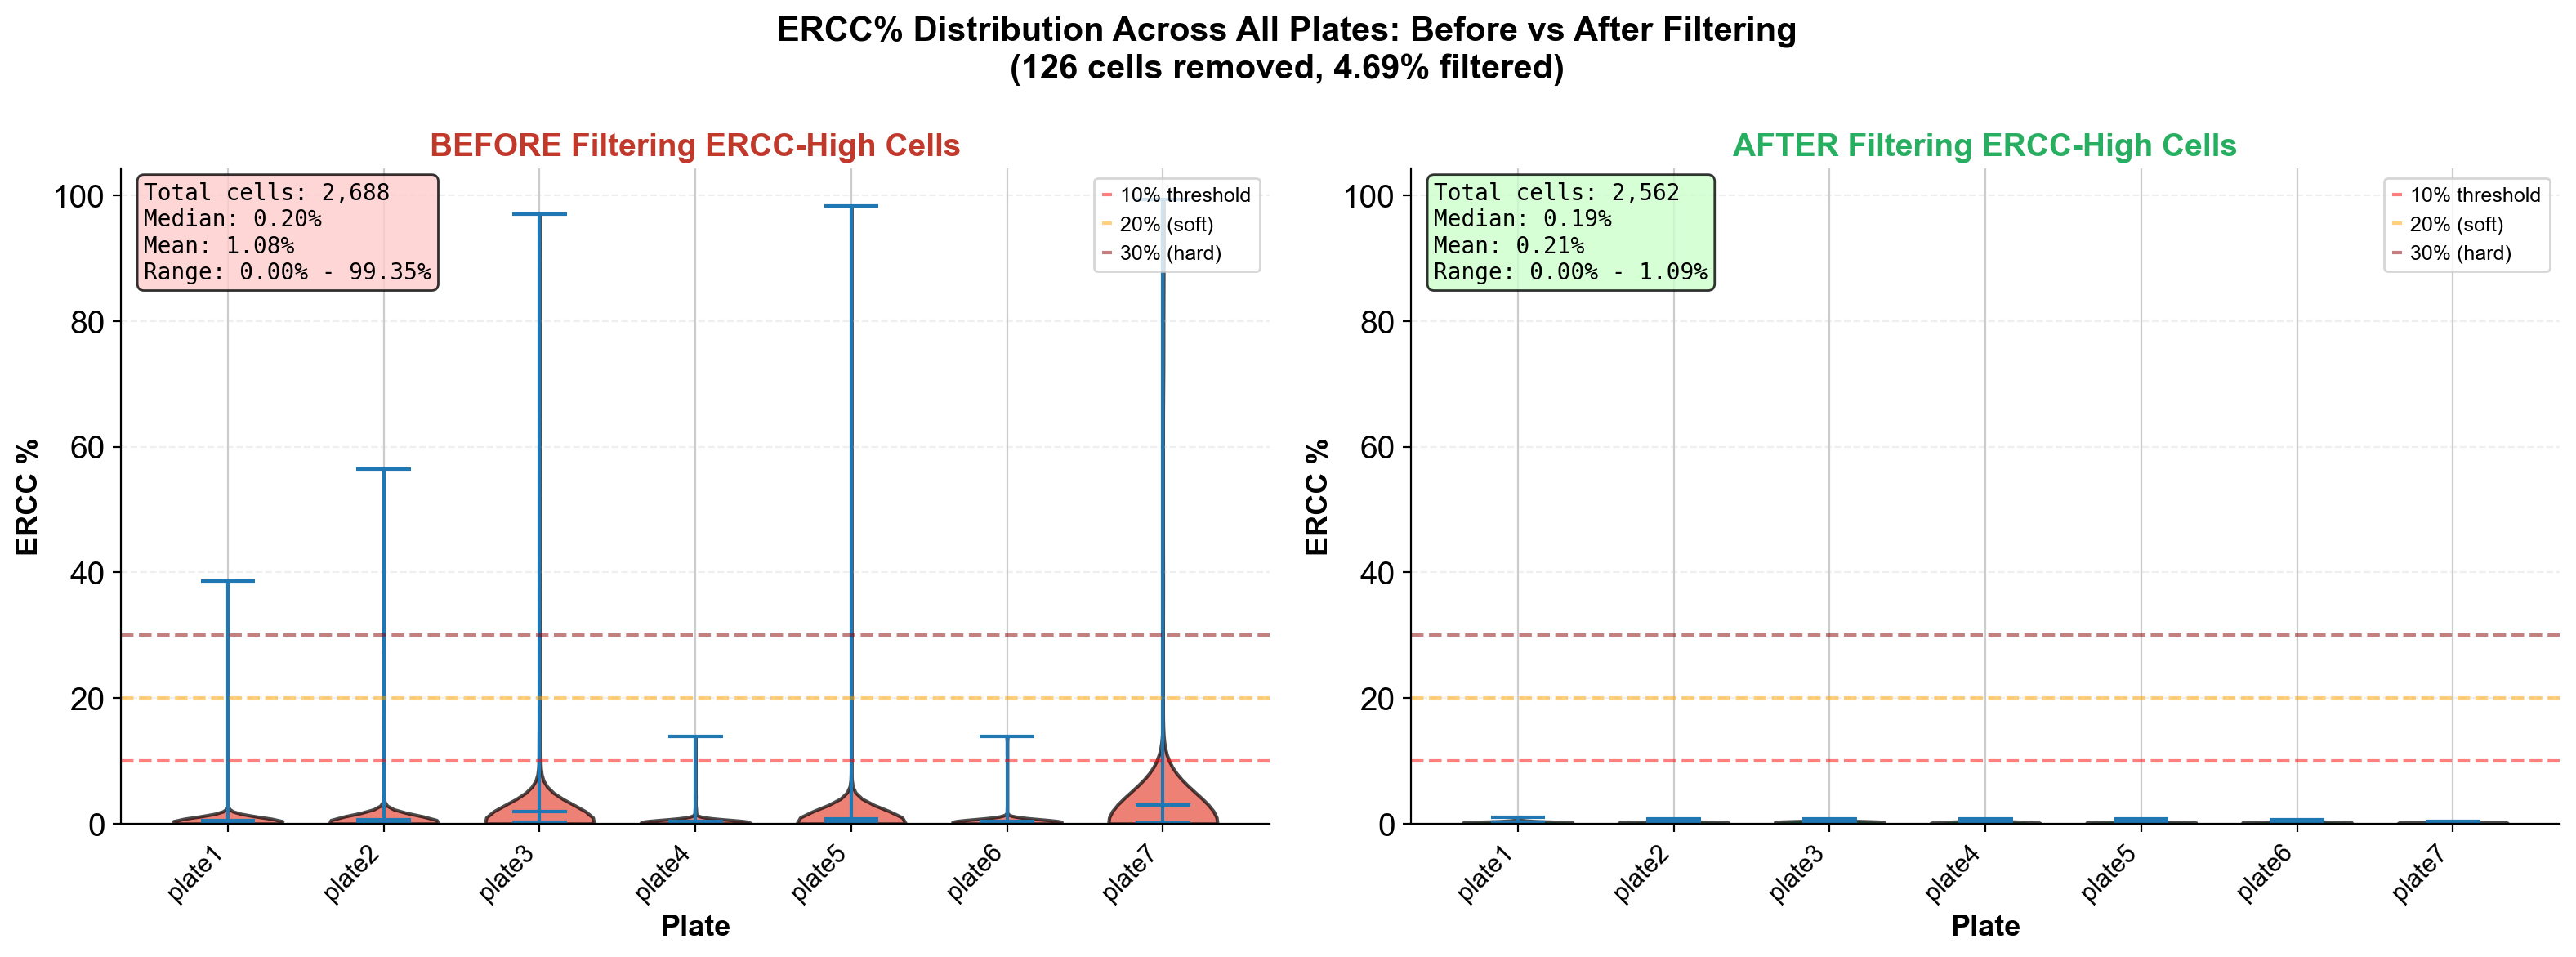


🎉 Pipeline complete!
   - Total plates processed: 7
   - Total cells retained: 2562


In [41]:
# ==================== Function 1: ERCC QC Processing ====================

def process_ercc_qc(adata, z_threshold=3.0, soft_hi=20.0, hard_hi=30.0, couple_ngenes=True):
    """
    One-stop ERCC quality control: calculate metrics, flag outliers, filter and cleanup
    Uses MAD (Median Absolute Deviation) method for outlier detection
    
    Parameters:
    -----------
    adata : AnnData
        Single-cell data containing ERCC spike-ins
    z_threshold : float
        MAD Z-score threshold for ERCC outlier detection, default 3.0
    soft_hi : float
        Soft upper threshold (%) for ERCC content, default 20.0
    hard_hi : float
        Hard upper threshold (%) for ERCC content, default 30.0
    couple_ngenes : bool
        Whether to couple with n_genes outlier detection, default True
        
    Returns:
    --------
    AnnData : Cleaned data (with ERCC genes and outlier cells removed)
    """
    plate_name = adata.obs['plate'].iloc[0] if 'plate' in adata.obs.columns else 'Unknown'
    print(f"\n{'='*70}")
    print(f"Processing Plate: {plate_name}")
    print(f"{'='*70}")
    
    # Step 1: Ensure ERCC annotation exists
    if 'ercc' not in adata.var.columns:
        adata.var['ercc'] = adata.var_names.str.startswith(('ERCC-', 'ERCC'), na=False)
    
    # Step 2: Calculate pct_ERCC (using raw counts)
    X = adata.raw.X if adata.raw is not None else adata.X
    ercc_mask = adata.var['ercc'].to_numpy()
    ercc_counts = np.asarray(X[:, ercc_mask].sum(axis=1)).ravel()
    total_counts = np.asarray(X.sum(axis=1)).ravel()
    total_counts = np.clip(total_counts, 1, None)
    pct_ercc = 100.0 * ercc_counts / total_counts
    adata.obs['pct_ERCC'] = pct_ercc
    
    # Print ERCC statistics
    if adata.var['ercc'].any():
        print(f"\n📊 ERCC Statistics:")
        print(f"  Mean: {pct_ercc.mean():.2f}% | Median: {np.median(pct_ercc):.2f}%")
        print(f"  Range: {pct_ercc.min():.2f}% - {pct_ercc.max():.2f}%")
        
        high_ercc = (pct_ercc > 10).sum()
        print(f"  {'⚠️' if high_ercc > 0 else '✅'} {high_ercc} cells with ERCC% > 10%")
    
    # Step 3: Calculate MAD Z-score
    med = np.median(pct_ercc)
    mad = np.median(np.abs(pct_ercc - med))
    scale = 1.4826 * mad if mad > 0 else 1.0
    zscore = np.abs(pct_ercc - med) / scale
    adata.obs['ERCC_z'] = zscore
    
    print(f"\n📐 MAD Statistics:")
    print(f"  Median: {med:.2f}% | MAD: {mad:.2f} | Scale: {scale:.2f}")
    
    # Step 4: Calculate n_genes outliers (optional coupling)
    if couple_ngenes:
        if 'n_genes_by_counts' not in adata.obs.columns:
            sc.pp.calculate_qc_metrics(adata, inplace=True)
        
        ng = adata.obs['n_genes_by_counts'].values
        ng_med = np.median(ng)
        ng_mad = np.median(np.abs(ng - ng_med)) * 1.4826
        ng_low = ng < (ng_med - 1.0 * ng_mad)
        n_low_genes = int(ng_low.sum())
        print(f"  Low gene count cells: {n_low_genes} / {adata.n_obs} (< {ng_med - 1.0 * ng_mad:.0f} genes)")
    else:
        ng_low = np.full(adata.n_obs, True, dtype=bool)
    
    # Step 5: Combined rules to flag cells for removal
    drop = (
        ((zscore > z_threshold) & ng_low) |
        ((pct_ercc > soft_hi) & ng_low) |
        (pct_ercc > hard_hi)
    )
    adata.obs['qc_drop_ERCC'] = drop.astype(bool)
    
    n_before = adata.n_obs
    n_drop = int(drop.sum())
    print(f"\n🔍 Outlier Cell Flagging:")
    print(f"  - Z-score > {z_threshold} & low genes: {int(((zscore > z_threshold) & ng_low).sum())}")
    print(f"  - ERCC% > {soft_hi}% & low genes: {int(((pct_ercc > soft_hi) & ng_low).sum())}")
    print(f"  - ERCC% > {hard_hi}% (hard threshold): {int((pct_ercc > hard_hi).sum())}")
    print(f"  - Total flagged for removal: {n_drop} / {n_before} ({n_drop/n_before*100:.1f}%)")
    
    # Step 6: Filter cells
    adata = adata[~adata.obs['qc_drop_ERCC']].copy()
    print(f"✂️  Cells after filtering: {n_before} → {adata.n_obs}")
    
    # Step 7: Remove ERCC genes
    if 'ercc' in adata.var.columns:
        n_genes_before = adata.n_vars
        adata = adata[:, ~adata.var['ercc']].copy()
        print(f"✂️  Removed ERCC genes: {n_genes_before} → {adata.n_vars} endogenous genes")
    
    print(f"\n✅ Processing complete!")
    return adata


def batch_process_ercc(adatas_list, **kwargs):
    """
    Batch process ERCC QC for multiple plates
    
    Parameters:
    -----------
    adatas_list : list of AnnData
        List of AnnData objects containing ERCC spike-ins
    **kwargs : additional parameters to pass to process_ercc_qc
        
    Returns:
    --------
    list of AnnData : List of cleaned data
    """
    print(f"\n{'='*70}")
    print(f"Starting batch processing for {len(adatas_list)} plates")
    print(f"{'='*70}")
    
    adatas_clean = []
    for i, adata in enumerate(adatas_list, 1):
        print(f"\n[{i}/{len(adatas_list)}]", end=" ")
        adata_clean = process_ercc_qc(adata, **kwargs)
        adatas_clean.append(adata_clean)
    
    print(f"\n\n{'='*70}")
    print(f"✅ All complete! Processed {len(adatas_clean)} plates")
    print(f"{'='*70}")
    
    return adatas_clean


# ==================== Function 2: Visualization ====================

def merge_and_plot_ercc_comparison(adatas_before, adatas_after, output_dir):
    """
    Compare ERCC percentage before and after filtering outlier cells
    - Print cell count statistics in table format
    - Plot ERCC% distribution: all plates before (left) vs all plates after (right)
    
    Parameters:
    -----------
    adatas_before : list of AnnData
        List of AnnData objects BEFORE filtering (with ERCC genes and outlier cells)
    adatas_after : list of AnnData
        List of AnnData objects AFTER filtering outlier cells (with ERCC genes, before removal)
    output_dir : Path or str
        Directory to save the plot
        
    Returns:
    --------
    tuple of (merged_before, merged_after) : Merged AnnData objects
    """
    # Merge all plates - BEFORE filtering
    print(f"\nMerging {len(adatas_before)} plates (before filtering)...")
    plate_keys_before = [adata.obs['plate'].iloc[0] for adata in adatas_before]
    merged_before = sc.concat(adatas_before, join='outer', label='plate_id', keys=plate_keys_before)
    merged_before.obs['filter_status'] = 'Before'
    
    # Merge all plates - AFTER filtering
    print(f"Merging {len(adatas_after)} plates (after filtering)...")
    plate_keys_after = [adata.obs['plate'].iloc[0] for adata in adatas_after]
    merged_after = sc.concat(adatas_after, join='outer', label='plate_id', keys=plate_keys_after)
    merged_after.obs['filter_status'] = 'After'
    
    # Calculate total statistics
    n_before_total = len(merged_before)
    n_after_total = len(merged_after)
    n_removed_total = n_before_total - n_after_total
    pct_removed = (n_removed_total / n_before_total * 100) if n_before_total > 0 else 0
    
    # ========== PRINT CELL COUNT TABLE ==========
    print(f"\n{'='*80}")
    print(f"📊 CELL COUNT SUMMARY (Filter Before vs After)")
    print(f"{'='*80}")
    print(f"{'Plate':<20} {'Before':<12} {'After':<12} {'Removed':<12} {'% Removed':<12}")
    print("-" * 80)
    
    for plate in plate_keys_before:
        before_count = (merged_before.obs['plate_id'] == plate).sum()
        after_count = (merged_after.obs['plate_id'] == plate).sum()
        removed = before_count - after_count
        pct = (removed / before_count * 100) if before_count > 0 else 0
        print(f"{plate:<20} {before_count:<12} {after_count:<12} {removed:<12} {pct:<12.2f}")
    
    print("-" * 80)
    print(f"{'TOTAL':<20} {n_before_total:<12} {n_after_total:<12} {n_removed_total:<12} {pct_removed:<12.2f}")
    print(f"{'='*80}\n")
    
    # ========== PLOT: ALL PLATES BEFORE (LEFT) VS ALL PLATES AFTER (RIGHT) ==========
    if 'pct_ERCC' not in merged_before.obs.columns or 'pct_ERCC' not in merged_after.obs.columns:
        print("⚠️  Warning: 'pct_ERCC' column not found. Skipping plot.")
        return merged_before, merged_after
    
    print("Generating ERCC% distribution plots...")
    
    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(16, 6))
    
    # ========== LEFT PLOT: BEFORE FILTERING ==========
    plate_names = plate_keys_before
    data_before = [merged_before[merged_before.obs['plate_id'] == plate].obs['pct_ERCC'].values 
                   for plate in plate_names]
    
    positions_before = np.arange(len(plate_names))
    parts_before = ax_before.violinplot(data_before, 
                                       positions=positions_before,
                                       widths=0.7,
                                       showmeans=True,
                                       showmedians=True,
                                       showextrema=True)
    
    # Color all violins in red (before filtering)
    for pc in parts_before['bodies']:
        pc.set_facecolor('#e74c3c')
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1.5)
    
    # Add threshold lines
    ax_before.axhline(10, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='10% threshold')
    ax_before.axhline(20, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='20% (soft)')
    ax_before.axhline(30, color='darkred', linestyle='--', alpha=0.5, linewidth=1.5, label='30% (hard)')
    
    # Add overall statistics
    all_before = merged_before.obs['pct_ERCC'].values
    stats_text_before = (f"Total cells: {n_before_total:,}\n"
                        f"Median: {np.median(all_before):.2f}%\n"
                        f"Mean: {np.mean(all_before):.2f}%\n"
                        f"Range: {np.min(all_before):.2f}% - {np.max(all_before):.2f}%")
    
    ax_before.text(0.02, 0.98, stats_text_before, transform=ax_before.transAxes,
                  fontsize=10, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8),
                  family='monospace')
    
    # Formatting
    ax_before.set_xticks(positions_before)
    ax_before.set_xticklabels(plate_names, rotation=45, ha='right', fontsize=11)
    ax_before.set_xlabel('Plate', fontsize=13, fontweight='bold')
    ax_before.set_ylabel('ERCC %', fontsize=13, fontweight='bold')
    ax_before.set_title('BEFORE Filtering ERCC-High Cells', 
                       fontsize=14, fontweight='bold', color='#c0392b')
    ax_before.legend(loc='upper right', fontsize=9)
    ax_before.grid(axis='y', alpha=0.3, linestyle='--')
    ax_before.spines['top'].set_visible(False)
    ax_before.spines['right'].set_visible(False)
    
    # ========== RIGHT PLOT: AFTER FILTERING ==========
    data_after = [merged_after[merged_after.obs['plate_id'] == plate].obs['pct_ERCC'].values 
                  for plate in plate_names]
    
    positions_after = np.arange(len(plate_names))
    parts_after = ax_after.violinplot(data_after, 
                                     positions=positions_after,
                                     widths=0.7,
                                     showmeans=True,
                                     showmedians=True,
                                     showextrema=True)
    
    # Color all violins in green (after filtering)
    for pc in parts_after['bodies']:
        pc.set_facecolor('#2ecc71')
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1.5)
    
    # Add threshold lines
    ax_after.axhline(10, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='10% threshold')
    ax_after.axhline(20, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='20% (soft)')
    ax_after.axhline(30, color='darkred', linestyle='--', alpha=0.5, linewidth=1.5, label='30% (hard)')
    
    # Add overall statistics
    all_after = merged_after.obs['pct_ERCC'].values
    stats_text_after = (f"Total cells: {n_after_total:,}\n"
                       f"Median: {np.median(all_after):.2f}%\n"
                       f"Mean: {np.mean(all_after):.2f}%\n"
                       f"Range: {np.min(all_after):.2f}% - {np.max(all_after):.2f}%")
    
    ax_after.text(0.02, 0.98, stats_text_after, transform=ax_after.transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.8),
                 family='monospace')
    
    # Formatting
    ax_after.set_xticks(positions_after)
    ax_after.set_xticklabels(plate_names, rotation=45, ha='right', fontsize=11)
    ax_after.set_xlabel('Plate', fontsize=13, fontweight='bold')
    ax_after.set_ylabel('ERCC %', fontsize=13, fontweight='bold')
    ax_after.set_title('AFTER Filtering ERCC-High Cells', 
                      fontsize=14, fontweight='bold', color='#27ae60')
    ax_after.legend(loc='upper right', fontsize=9)
    ax_after.grid(axis='y', alpha=0.3, linestyle='--')
    ax_after.spines['top'].set_visible(False)
    ax_after.spines['right'].set_visible(False)
    
    # Make y-axis consistent between both plots
    y_max = max(ax_before.get_ylim()[1], ax_after.get_ylim()[1])
    ax_before.set_ylim(0, y_max)
    ax_after.set_ylim(0, y_max)
    
    # Overall title
    fig.suptitle(f'ERCC% Distribution Across All Plates: Before vs After Filtering\n'
                f'({n_removed_total:,} cells removed, {pct_removed:.2f}% filtered)', 
                fontsize=15, fontweight='bold')
    
    plt.tight_layout()
    
    # Save plot
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    filename = output_dir / 'ercc_percentage_before_after_comparison.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n💾 Saved: {filename}")
    plt.show()
    
    return merged_before, merged_after


# ==================== Usage Example ====================

# # Step 1: Load your data (example)
# adatas_with_ercc = [...]  # Your list of AnnData objects with ERCC

# Step 2: Keep a copy BEFORE filtering (for comparison)
adatas_before_filtering = [adata.copy() for adata in adatas_with_ercc]

# Step 3: Run ERCC QC to flag outliers
for adata in adatas_with_ercc:
    # Ensure ERCC annotation exists
    if 'ercc' not in adata.var.columns:
        adata.var['ercc'] = adata.var_names.str.startswith(('ERCC-', 'ERCC'), na=False)
    
    # Calculate pct_ERCC and flag outliers
    X = adata.raw.X if adata.raw is not None else adata.X
    ercc_mask = adata.var['ercc'].to_numpy()
    ercc_counts = np.asarray(X[:, ercc_mask].sum(axis=1)).ravel()
    total_counts = np.asarray(X.sum(axis=1)).ravel()
    total_counts = np.clip(total_counts, 1, None)
    pct_ercc = 100.0 * ercc_counts / total_counts
    adata.obs['pct_ERCC'] = pct_ercc
    
    # Calculate MAD Z-score and flag
    med = np.median(pct_ercc)
    mad = np.median(np.abs(pct_ercc - med))
    scale = 1.4826 * mad if mad > 0 else 1.0
    zscore = np.abs(pct_ercc - med) / scale
    
    # Flag outliers
    if 'n_genes_by_counts' not in adata.obs.columns:
        sc.pp.calculate_qc_metrics(adata, inplace=True)
    ng = adata.obs['n_genes_by_counts'].values
    ng_med = np.median(ng)
    ng_mad = np.median(np.abs(ng - ng_med)) * 1.4826
    ng_low = ng < (ng_med - 1.0 * ng_mad)
    
    drop = ((zscore > 3.0) & ng_low) | ((pct_ercc > 20.0) & ng_low) | (pct_ercc > 30.0)
    adata.obs['qc_drop_ERCC'] = drop.astype(bool)

# Step 4: Filter outlier cells BUT keep ERCC genes (for comparison plot)
adatas_after_filtering = []
for adata in adatas_with_ercc:
    adata_filtered = adata[~adata.obs['qc_drop_ERCC']].copy()
    adatas_after_filtering.append(adata_filtered)

# Step 5: Generate comparison plots (before vs after filtering)
output_dir = Path('./qc_results')
merged_before, merged_after = merge_and_plot_ercc_comparison(
    adatas_before_filtering,
    adatas_after_filtering,
    output_dir
)

# Step 6: NOW remove ERCC genes (for downstream analysis)
adatas_clean = []
for adata in adatas_after_filtering:
    adata_clean = adata[:, ~adata.var['ercc']].copy()
    adatas_clean.append(adata_clean)

print("\n🎉 Pipeline complete!")
print(f"   - Total plates processed: {len(adatas_clean)}")
print(f"   - Total cells retained: {sum(adata.n_obs for adata in adatas_clean)}")

---

## Step 2: Calculate QC Metrics


Calculate percentages for:
- Mitochondrial genes (`mt:` for Drosophila)
- GFP marker (`mCD8-GFP`)
- Neuronal markers: `elav`, `brp`, `Syt1`, `nSyb`, `CadN`

In [42]:
def calculate_custom_qc_metrics(adata):
    """
    Calculate QC metrics including Drosophila-specific markers
    Replicates: PercentageFeatureSet() calls
    """
    print(f"\nCalculating QC metrics for {adata.obs['plate'].iloc[0]}...")
    # Mitochondrial genes (Drosophila uses 'mt:' prefix)
    adata.var['mt'] = adata.var_names.str.startswith('mt:')
    
    # Specific gene markers (exact match or contains)
    adata.var['mCD8_GFP'] = adata.var_names.str.contains('mCD8-GFP')
    adata.var['elav'] = adata.var_names.str.contains('elav')
    adata.var['brp'] = adata.var_names.str.contains('brp')
    adata.var['Syt1'] = adata.var_names.str.contains('Syt1')
    adata.var['nSyb'] = adata.var_names.str.contains('nSyb')
    adata.var['CadN'] = adata.var_names.str.contains('CadN')
    
    # Calculate percentages for each marker set
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=['mt', 'mCD8_GFP', 'elav', 'brp', 'Syt1', 'nSyb', 'CadN'],
        percent_top=None,
        log1p=False,
        inplace=True
    )
    
    # Add Seurat-style column names
    adata.obs['n_genes'] = adata.obs['n_genes_by_counts']
    adata.obs['n_counts'] = adata.obs['total_counts']
    adata.obs['percent.mt'] = adata.obs['pct_counts_mt']
    adata.obs['percent.mCD8GFP'] = adata.obs['pct_counts_mCD8_GFP']
    adata.obs['percent.elav'] = adata.obs['pct_counts_elav']
    adata.obs['percent.brp'] = adata.obs['pct_counts_brp']
    adata.obs['percent.Syt1'] = adata.obs['pct_counts_Syt1']
    adata.obs['percent.nSyb'] = adata.obs['pct_counts_nSyb']
    adata.obs['percent.CadN'] = adata.obs['pct_counts_CadN']
    
    print(f"  Mean counts: {adata.obs['n_counts'].mean():.0f}")
    print(f"  Mean genes: {adata.obs['n_genes'].mean():.0f}")
    print(f"  Mean mt%: {adata.obs['percent.mt'].mean():.2f}%")
    
    return adata

In [43]:
# Calculate QC for all plates
adatas_qc = []
for adata in adatas_clean:
    adata = calculate_custom_qc_metrics(adata)
    adatas_qc.append(adata)

print("\n✅ QC metrics calculated for all plates")


Calculating QC metrics for plate1...
  Mean counts: 1300470
  Mean genes: 2705
  Mean mt%: 0.96%

Calculating QC metrics for plate2...
  Mean counts: 1152641
  Mean genes: 2582
  Mean mt%: 1.24%

Calculating QC metrics for plate3...
  Mean counts: 1124602
  Mean genes: 2411
  Mean mt%: 2.00%

Calculating QC metrics for plate4...
  Mean counts: 957481
  Mean genes: 2588
  Mean mt%: 0.40%

Calculating QC metrics for plate5...
  Mean counts: 1228102
  Mean genes: 2858
  Mean mt%: 1.39%

Calculating QC metrics for plate6...
  Mean counts: 1290135
  Mean genes: 2742
  Mean mt%: 1.20%

Calculating QC metrics for plate7...
  Mean counts: 1859272
  Mean genes: 4579
  Mean mt%: 1.27%

✅ QC metrics calculated for all plates


---

## Step 3: Filter by Counts and Mitochondrial %



In [44]:
def filter_cells_seurat_style(adata, min_counts=100000, max_pct_mt=5):
    """
    Filter cells with Seurat-style thresholds
    Replicates: subset(x = plate1, subset = nCount_RNA > 100000 & percent.mt<5)
    """
    print(f"\nFiltering {adata.obs['plate'].iloc[0]}...")
    print(f"  Starting with {adata.n_obs} cells")
    
    # Filter by counts and mitochondrial percentage
    adata = adata[adata.obs['n_counts'] > min_counts, :]
    print(f"  After count filter (>{min_counts}): {adata.n_obs} cells")
    
    adata = adata[adata.obs['percent.mt'] < max_pct_mt, :]
    print(f"  After mt filter (<{max_pct_mt}%): {adata.n_obs} cells")
    
    return adata

In [45]:
# Filter all plates
adatas_filtered = []
for adata in adatas_qc:
    adata = filter_cells_seurat_style(adata, min_counts=min_counts, max_pct_mt=max_pct_mt)
    adatas_filtered.append(adata)

print("\n✅ Basic filtering complete for all plates")


Filtering plate1...
  Starting with 376 cells
  After count filter (>100000): 351 cells
  After mt filter (<5%): 350 cells

Filtering plate2...
  Starting with 375 cells
  After count filter (>100000): 342 cells
  After mt filter (<5%): 342 cells

Filtering plate3...
  Starting with 354 cells
  After count filter (>100000): 315 cells
  After mt filter (<5%): 313 cells

Filtering plate4...
  Starting with 369 cells
  After count filter (>100000): 352 cells
  After mt filter (<5%): 352 cells

Filtering plate5...
  Starting with 373 cells
  After count filter (>100000): 345 cells
  After mt filter (<5%): 345 cells

Filtering plate6...
  Starting with 370 cells
  After count filter (>100000): 345 cells
  After mt filter (<5%): 345 cells

Filtering plate7...
  Starting with 345 cells
  After count filter (>100000): 333 cells
  After mt filter (<5%): 333 cells

✅ Basic filtering complete for all plates


### Visualize after basic filtering


Merging plates BEFORE basic filtering...
Merging plates AFTER basic filtering...

📊 CELL COUNT SUMMARY (Basic Filtering: Before vs After)
Plate                Before       After        Removed      % Removed   
--------------------------------------------------------------------------------
plate1               376          350          26           6.91        
plate2               375          342          33           8.80        
plate3               354          313          41           11.58       
plate4               369          352          17           4.61        
plate5               373          345          28           7.51        
plate6               370          345          25           6.76        
plate7               345          333          12           3.48        
--------------------------------------------------------------------------------
TOTAL                2562         2380         182          7.10        

Generating QC metrics comparison plots...

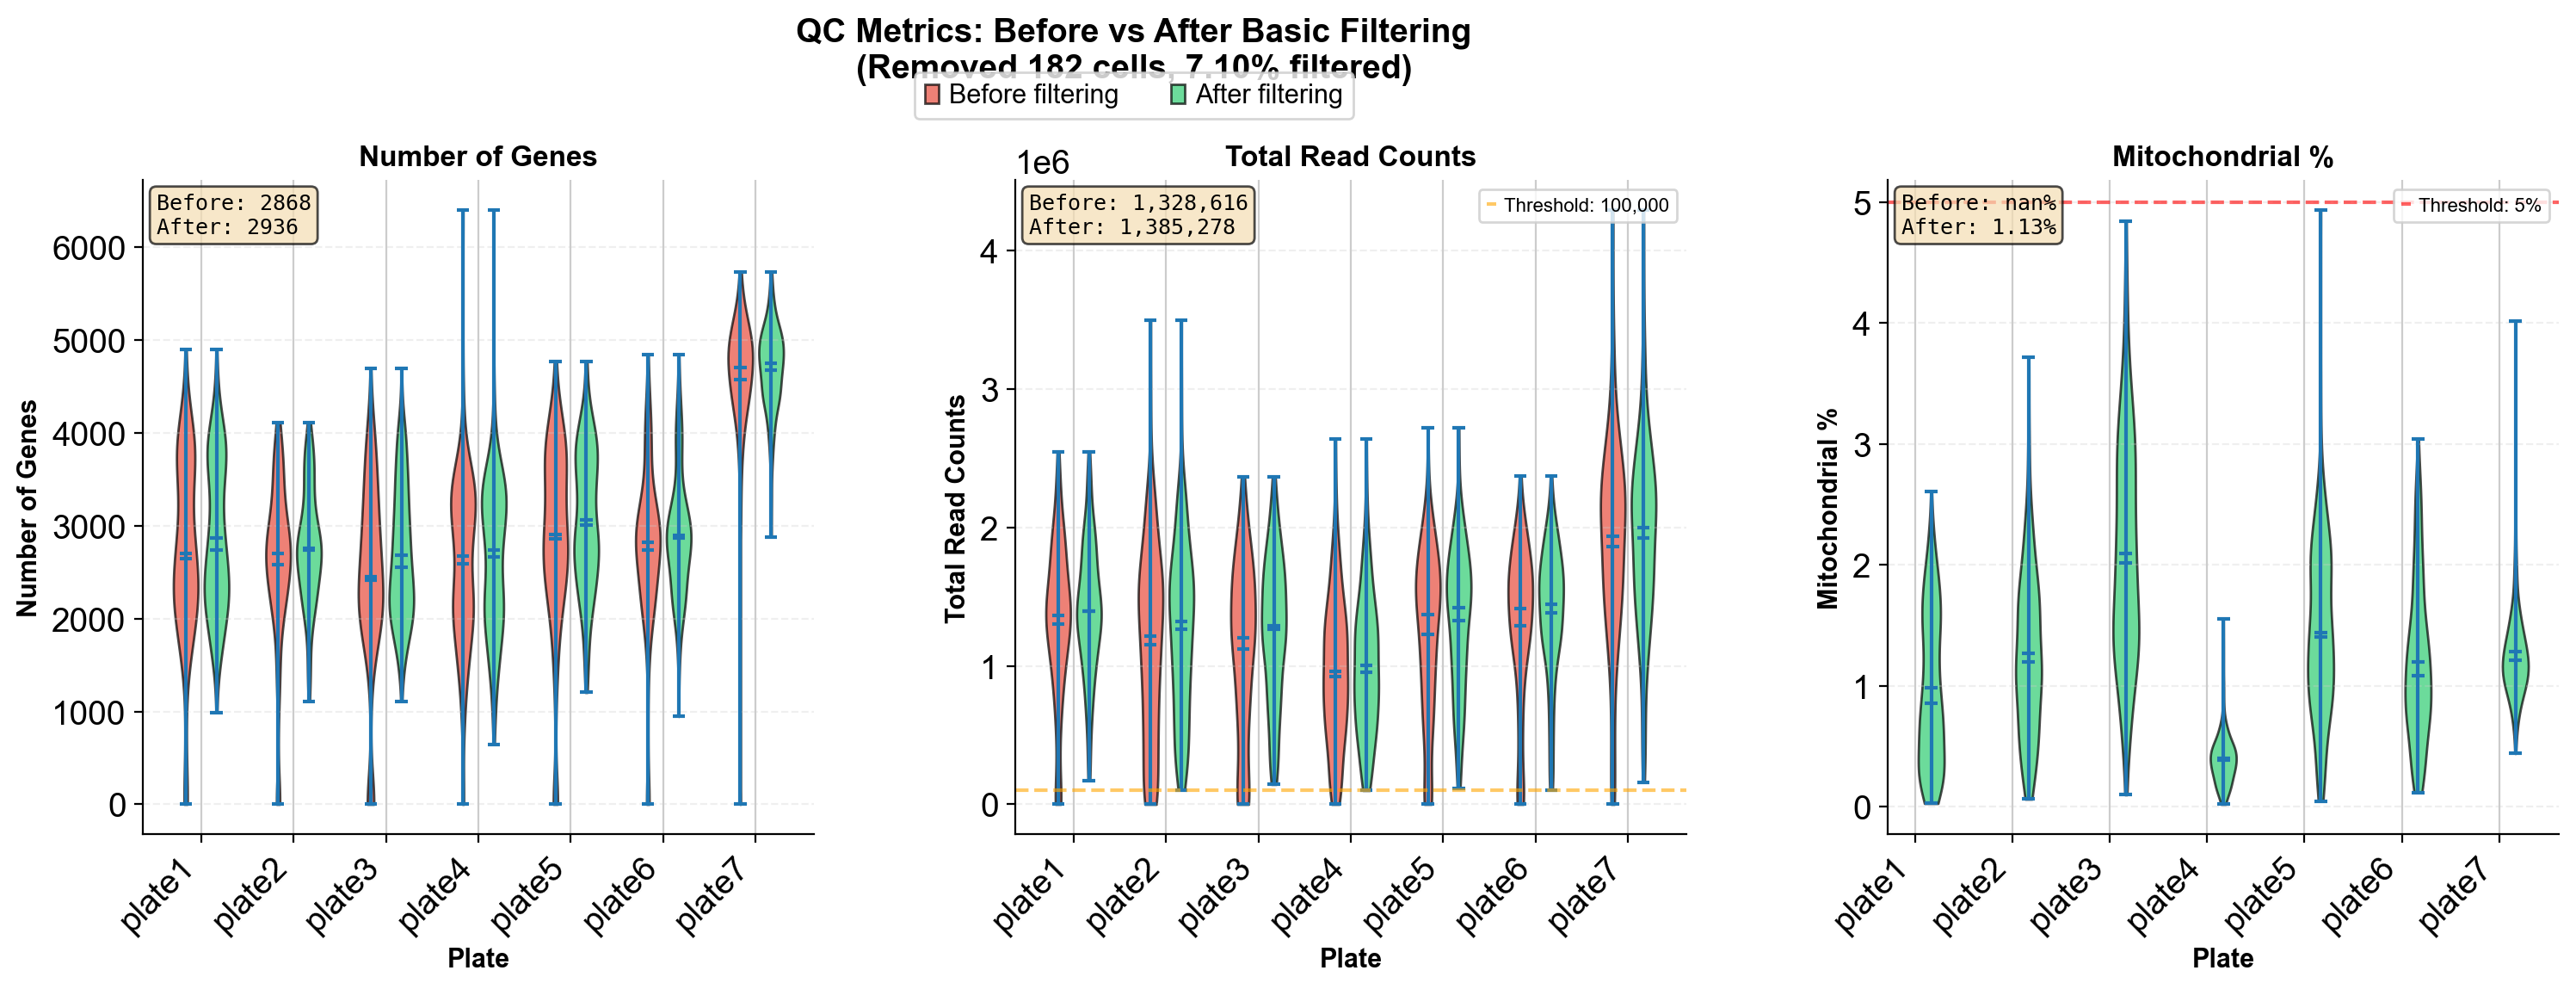


✅ QC visualization complete!


In [46]:
# ==================== Visualize Basic QC Metrics: Before vs After Filtering ====================

# Merge data - BEFORE basic filtering
print("\nMerging plates BEFORE basic filtering...")
merge_before_basic = sc.concat(adatas_qc, join='outer', label='plate_id',
                               keys=[adata.obs['plate'].iloc[0] for adata in adatas_qc])
merge_before_basic.obs['filter_status'] = 'Before'

# Merge data - AFTER basic filtering
print("Merging plates AFTER basic filtering...")
merge_after_basic = sc.concat(adatas_filtered, join='outer', label='plate_id',
                              keys=[adata.obs['plate'].iloc[0] for adata in adatas_filtered])
merge_after_basic.obs['filter_status'] = 'After'

# Calculate statistics
n_before_total = len(merge_before_basic)
n_after_total = len(merge_after_basic)
n_removed_total = n_before_total - n_after_total
pct_removed = (n_removed_total / n_before_total * 100) if n_before_total > 0 else 0

# ========== PRINT CELL COUNT TABLE ==========
print(f"\n{'='*80}")
print(f"📊 CELL COUNT SUMMARY (Basic Filtering: Before vs After)")
print(f"{'='*80}")
print(f"{'Plate':<20} {'Before':<12} {'After':<12} {'Removed':<12} {'% Removed':<12}")
print("-" * 80)

plate_names = [adata.obs['plate'].iloc[0] for adata in adatas_qc]
for plate in plate_names:
    before_count = (merge_before_basic.obs['plate_id'] == plate).sum()
    after_count = (merge_after_basic.obs['plate_id'] == plate).sum()
    removed = before_count - after_count
    pct = (removed / before_count * 100) if before_count > 0 else 0
    print(f"{plate:<20} {before_count:<12} {after_count:<12} {removed:<12} {pct:<12.2f}")

print("-" * 80)
print(f"{'TOTAL':<20} {n_before_total:<12} {n_after_total:<12} {n_removed_total:<12} {pct_removed:<12.2f}")
print(f"{'='*80}\n")

# ========== PLOT: QC METRICS BEFORE VS AFTER ==========
print("Generating QC metrics comparison plots...")

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, wspace=0.3)

metrics = ['n_genes', 'n_counts', 'percent.mt']
titles = ['Number of Genes', 'Total Read Counts', 'Mitochondrial %']
colors_before = '#e74c3c'  # Red
colors_after = '#2ecc71'   # Green

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = fig.add_subplot(gs[0, idx])
    
    # Get data for all plates
    plate_names_sorted = sorted(merge_before_basic.obs['plate_id'].unique())
    positions = []
    data_to_plot = []
    colors = []
    
    for i, plate in enumerate(plate_names_sorted):
        # Before filtering
        before_data = merge_before_basic[merge_before_basic.obs['plate_id'] == plate].obs[metric].values
        positions.append(i * 3)
        data_to_plot.append(before_data)
        colors.append(colors_before)
        
        # After filtering
        after_data = merge_after_basic[merge_after_basic.obs['plate_id'] == plate].obs[metric].values
        positions.append(i * 3 + 1)
        data_to_plot.append(after_data)
        colors.append(colors_after)
    
    # Create violin plot
    parts = ax.violinplot(data_to_plot, positions=positions, widths=0.8,
                          showmeans=True, showmedians=True, showextrema=True)
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    
    # Add threshold lines for specific metrics
    if metric == 'n_counts':
        ax.axhline(min_counts, color='orange', linestyle='--', alpha=0.6, 
                  linewidth=1.5, label=f'Threshold: {min_counts:,}')
        ax.legend(loc='upper right', fontsize=8)
    elif metric == 'percent.mt':
        ax.axhline(max_pct_mt, color='red', linestyle='--', alpha=0.6, 
                  linewidth=1.5, label=f'Threshold: {max_pct_mt}%')
        ax.legend(loc='upper right', fontsize=8)
    
    # Set x-axis labels
    plate_positions = [i * 3 + 0.5 for i in range(len(plate_names_sorted))]
    ax.set_xticks(plate_positions)
    ax.set_xticklabels(plate_names_sorted, rotation=45, ha='right')
    
    # Labels and formatting
    ax.set_xlabel('Plate', fontsize=11, fontweight='bold')
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add statistics box
    before_median = np.median(merge_before_basic.obs[metric])
    after_median = np.median(merge_after_basic.obs[metric])
    
    if metric == 'percent.mt':
        stats_text = f"Before: {before_median:.2f}%\nAfter: {after_median:.2f}%"
    elif metric == 'n_counts':
        stats_text = f"Before: {before_median:,.0f}\nAfter: {after_median:,.0f}"
    else:
        stats_text = f"Before: {before_median:.0f}\nAfter: {after_median:.0f}"
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
           fontsize=9, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
           family='monospace')

# Add custom legend for before/after at the top

legend_elements = [
    Patch(facecolor=colors_before, alpha=0.7, label='Before filtering', edgecolor='black'),
    Patch(facecolor=colors_after, alpha=0.7, label='After filtering', edgecolor='black')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, 
          fontsize=11, frameon=True, bbox_to_anchor=(0.5, 1.05))

fig.suptitle(f'QC Metrics: Before vs After Basic Filtering\n'
            f'(Removed {n_removed_total:,} cells, {pct_removed:.2f}% filtered)', 
            fontsize=14, fontweight='bold', y=1.1)

# plt.tight_layout()

# Save plot
output_dir = Path(output_dir) if isinstance(output_dir, str) else output_dir
output_dir.mkdir(parents=True, exist_ok=True)
filename = output_dir / 'qc_before_after_basic_filtering.png'
plt.savefig(filename, dpi=300)
print(f"\n💾 Saved: {filename}")
plt.show()

print("\n✅ QC visualization complete!")

---

## Step 4: Filter by Neuronal Markers

This ensures we only keep **GFP+ neurons with functional synapses**.

In [47]:
def filter_by_markers(adata):
    """
    Filter cells requiring expression of all neuronal markers
    Replicates: subset(x = plate1, subset = percent.mCD8GFP>0 & percent.elav>0 & ...)
    """
    print(f"\nFiltering by marker expression for {adata.obs['plate'].iloc[0]}...")
    print(f"  Starting with {adata.n_obs} cells")
    
    # Require all markers to be expressed (percent > 0)
    mask = (
        (adata.obs['percent.mCD8GFP'] > 0) &
        (adata.obs['percent.elav'] > 0) &
        (adata.obs['percent.brp'] > 0) &
        (adata.obs['percent.Syt1'] > 0) &
        (adata.obs['percent.nSyb'] > 0) &
        (adata.obs['percent.CadN'] > 0)
    )
    
    adata = adata[mask, :]
    print(f"  After marker filter: {adata.n_obs} cells")
    
    return adata

In [48]:
# Apply marker filtering to all plates
adatas_marker_filtered = []
for adata in adatas_filtered:
    adata = filter_by_markers(adata)
    adatas_marker_filtered.append(adata)

print("\n✅ Marker filtering complete for all plates")


Filtering by marker expression for plate1...
  Starting with 350 cells
  After marker filter: 276 cells

Filtering by marker expression for plate2...
  Starting with 342 cells
  After marker filter: 295 cells

Filtering by marker expression for plate3...
  Starting with 313 cells
  After marker filter: 230 cells

Filtering by marker expression for plate4...
  Starting with 352 cells
  After marker filter: 226 cells

Filtering by marker expression for plate5...
  Starting with 345 cells
  After marker filter: 302 cells

Filtering by marker expression for plate6...
  Starting with 345 cells
  After marker filter: 302 cells

Filtering by marker expression for plate7...
  Starting with 333 cells
  After marker filter: 304 cells

✅ Marker filtering complete for all plates


### Visualize after marker filtering


Merging plates BEFORE marker filtering...
Merging plates AFTER marker filtering...

📊 CELL COUNT SUMMARY (Marker Filtering: Before vs After)
Plate                Before       After        Removed      % Removed   
--------------------------------------------------------------------------------
plate1               350          276          74           21.14       
plate2               342          295          47           13.74       
plate3               313          230          83           26.52       
plate4               352          226          126          35.80       
plate5               345          302          43           12.46       
plate6               345          302          43           12.46       
plate7               333          304          29           8.71        
--------------------------------------------------------------------------------
TOTAL                2380         1935         445          18.70       

📋 Marker Expression Statistics (AFTER 

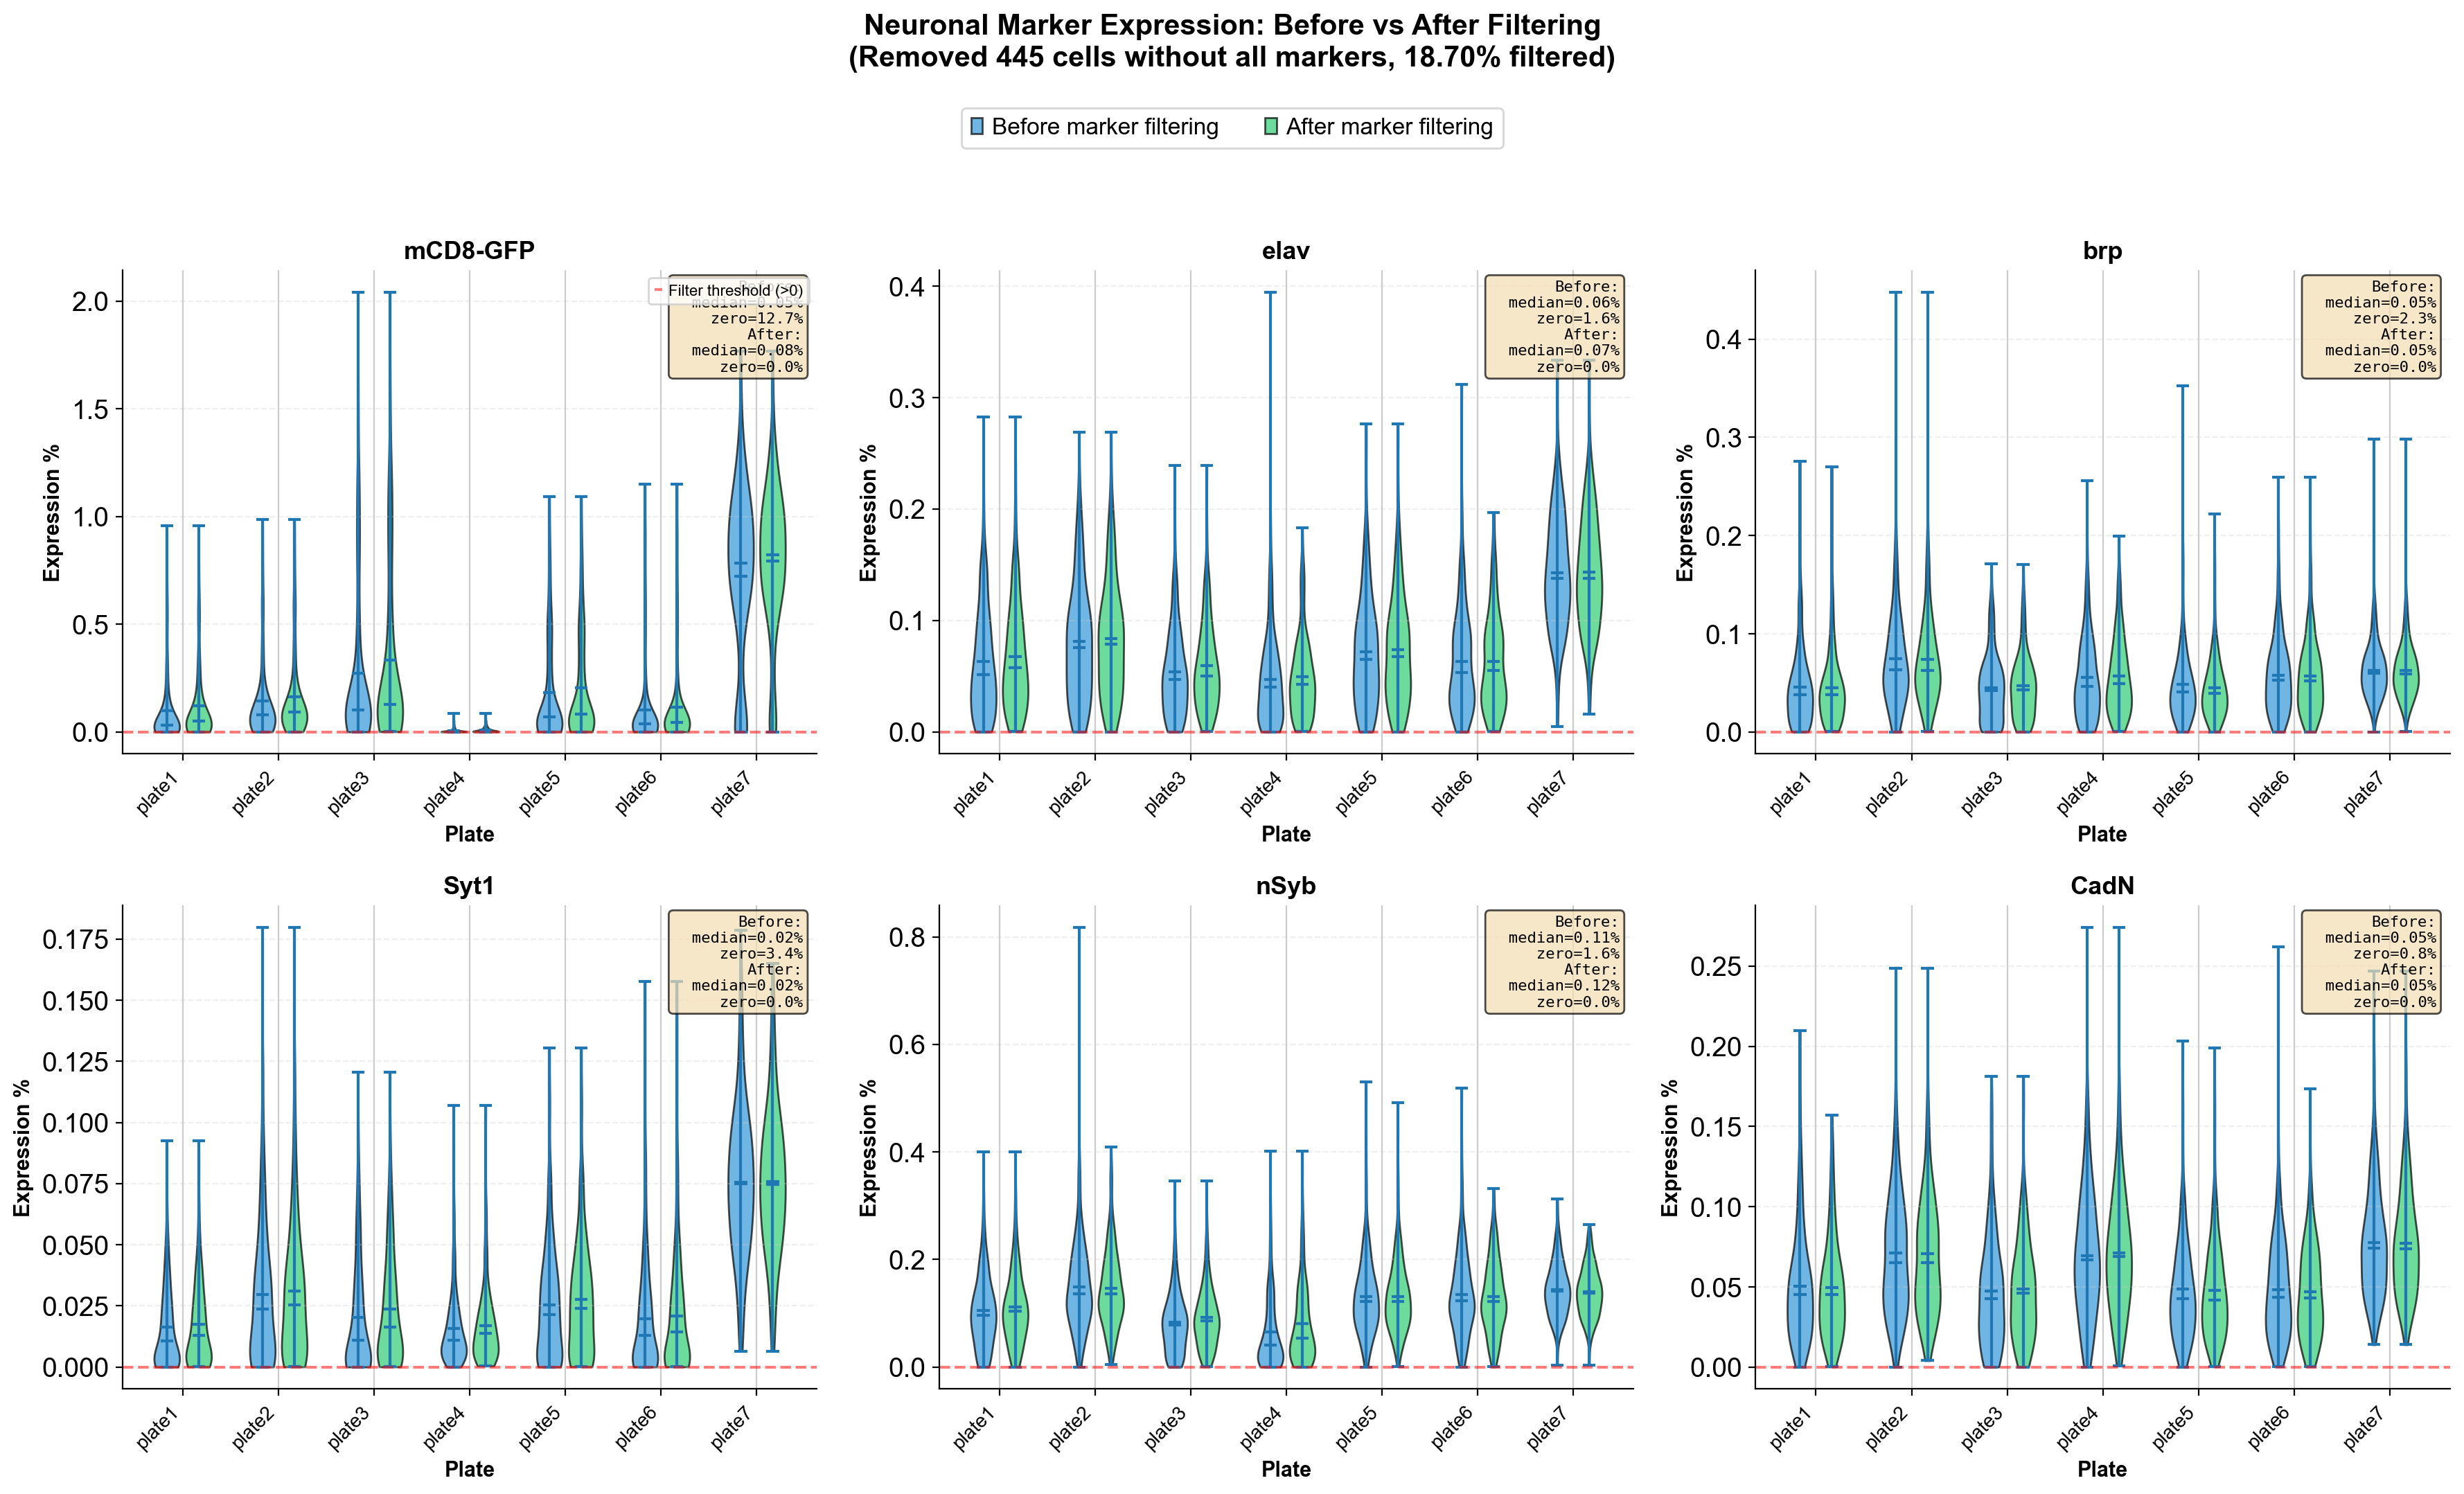


✅ Marker expression visualization complete!


In [49]:
# Merge data - BEFORE marker filtering
print("\nMerging plates BEFORE marker filtering...")
merge_before_markers = sc.concat(adatas_filtered, join='outer', label='plate_id',
                                 keys=[adata.obs['plate'].iloc[0] for adata in adatas_filtered])
merge_before_markers.obs['filter_status'] = 'Before'

# Merge data - AFTER marker filtering
print("Merging plates AFTER marker filtering...")
merge_after_markers = sc.concat(adatas_marker_filtered, join='outer', label='plate_id',
                                keys=[adata.obs['plate'].iloc[0] for adata in adatas_marker_filtered])
merge_after_markers.obs['filter_status'] = 'After'

# Calculate statistics
n_before_total = len(merge_before_markers)
n_after_total = len(merge_after_markers)
n_removed_total = n_before_total - n_after_total
pct_removed = (n_removed_total / n_before_total * 100) if n_before_total > 0 else 0

# ========== PRINT CELL COUNT TABLE ==========
print(f"\n{'='*80}")
print(f"📊 CELL COUNT SUMMARY (Marker Filtering: Before vs After)")
print(f"{'='*80}")
print(f"{'Plate':<20} {'Before':<12} {'After':<12} {'Removed':<12} {'% Removed':<12}")
print("-" * 80)

plate_names = [adata.obs['plate'].iloc[0] for adata in adatas_filtered]
for plate in plate_names:
    before_count = (merge_before_markers.obs['plate_id'] == plate).sum()
    after_count = (merge_after_markers.obs['plate_id'] == plate).sum()
    removed = before_count - after_count
    pct = (removed / before_count * 100) if before_count > 0 else 0
    print(f"{plate:<20} {before_count:<12} {after_count:<12} {removed:<12} {pct:<12.2f}")

print("-" * 80)
print(f"{'TOTAL':<20} {n_before_total:<12} {n_after_total:<12} {n_removed_total:<12} {pct_removed:<12.2f}")
print(f"{'='*80}\n")

# Print marker expression statistics
print(f"📋 Marker Expression Statistics (AFTER filtering):")
print(f"{'Marker':<20} {'Median %':<12} {'Mean %':<12} {'% Cells > 0':<15}")
print("-" * 60)
markers = ['mCD8GFP', 'elav', 'brp', 'Syt1', 'nSyb', 'CadN']
for marker in markers:
    col_name = f'percent.{marker}'
    if col_name in merge_after_markers.obs.columns:
        values = merge_after_markers.obs[col_name]
        median = np.median(values)
        mean = np.mean(values)
        pct_expressing = (values > 0).sum() / len(values) * 100
        print(f"{marker:<20} {median:<12.2f} {mean:<12.2f} {pct_expressing:<15.1f}")
print()

# ========== PLOT: MARKER EXPRESSION BEFORE VS AFTER ==========
print("Generating marker expression comparison plots...")

marker_keys = ['percent.mCD8GFP', 'percent.elav', 'percent.brp', 
               'percent.Syt1', 'percent.nSyb', 'percent.CadN']
marker_names = ['mCD8-GFP', 'elav', 'brp', 'Syt1', 'nSyb', 'CadN']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors_before = '#3498db'  # Blue
colors_after = '#2ecc71'   # Green

for idx, (marker_key, marker_name) in enumerate(zip(marker_keys, marker_names)):
    ax = axes[idx]
    
    if marker_key not in merge_before_markers.obs.columns:
        ax.text(0.5, 0.5, f'{marker_name}\nNot Available', 
               ha='center', va='center', fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    # Get data for all plates
    plate_names_sorted = sorted(merge_before_markers.obs['plate_id'].unique())
    positions = []
    data_to_plot = []
    colors = []
    
    for i, plate in enumerate(plate_names_sorted):
        # Before filtering
        before_data = merge_before_markers[merge_before_markers.obs['plate_id'] == plate].obs[marker_key].values
        positions.append(i * 3)
        data_to_plot.append(before_data)
        colors.append(colors_before)
        
        # After filtering
        after_data = merge_after_markers[merge_after_markers.obs['plate_id'] == plate].obs[marker_key].values
        positions.append(i * 3 + 1)
        data_to_plot.append(after_data)
        colors.append(colors_after)
    
    # Create violin plot
    parts = ax.violinplot(data_to_plot, positions=positions, widths=0.8,
                          showmeans=True, showmedians=True, showextrema=True)
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    
    # Add threshold line at 0 (filtering threshold)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, 
              label='Filter threshold (>0)')
    
    # Set x-axis labels
    plate_positions = [i * 3 + 0.5 for i in range(len(plate_names_sorted))]
    ax.set_xticks(plate_positions)
    ax.set_xticklabels(plate_names_sorted, rotation=45, ha='right', fontsize=10)
    
    # Labels and formatting
    ax.set_xlabel('Plate', fontsize=11, fontweight='bold')
    ax.set_ylabel('Expression %', fontsize=11, fontweight='bold')
    ax.set_title(f'{marker_name}', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend only to first subplot
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)
    
    # Add statistics box
    before_median = np.median(merge_before_markers.obs[marker_key])
    after_median = np.median(merge_after_markers.obs[marker_key])
    before_pct_zero = (merge_before_markers.obs[marker_key] == 0).sum() / len(merge_before_markers) * 100
    after_pct_zero = (merge_after_markers.obs[marker_key] == 0).sum() / len(merge_after_markers) * 100
    
    stats_text = (f"Before:\n"
                 f"  median={before_median:.2f}%\n"
                 f"  zero={before_pct_zero:.1f}%\n"
                 f"After:\n"
                 f"  median={after_median:.2f}%\n"
                 f"  zero={after_pct_zero:.1f}%")
    
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
           fontsize=8, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
           family='monospace')

# Add custom legend for before/after at the top
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_before, alpha=0.7, label='Before marker filtering', edgecolor='black'),
    Patch(facecolor=colors_after, alpha=0.7, label='After marker filtering', edgecolor='black')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, 
          fontsize=12, frameon=True, bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f'Neuronal Marker Expression: Before vs After Filtering\n'
            f'(Removed {n_removed_total:,} cells without all markers, {pct_removed:.2f}% filtered)', 
            fontsize=15, fontweight='bold', y=1.08)

plt.tight_layout()

# Save plot
output_dir = Path(output_dir) if isinstance(output_dir, str) else output_dir
output_dir.mkdir(parents=True, exist_ok=True)
filename = output_dir / 'marker_expression_before_after_filtering.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"\n💾 Saved: {filename}")
plt.show()

print("\n✅ Marker expression visualization complete!")

---

## Step 5: Normalize to log2(CPM+1)

$$CPM = \frac{counts}{total\_counts} \times 10^6$$
$$normalized = \log_2(CPM + 1)$$

In [50]:
def normalize_to_cpm_log2(adata):
    """
    Normalize to CPM and apply log2 transformation
    Replicates: normMat() function from CONICSmat (log2(CPM + 1))
    
    CPM = (counts / total_counts) * 1e6
    log2(CPM + 1)
    """
    print(f"\nNormalizing {adata.obs['plate'].iloc[0]} to log2(CPM+1)...")
    
    # Store raw counts
    adata.layers['counts'] = adata.X.copy()
    
    # Calculate CPM
    # Total counts per cell
    total_counts = np.array(adata.X.sum(axis=1)).flatten()
    
    # Normalize to counts per million
    cpm = (adata.X.T / total_counts * 1e6).T
    
    # Apply log2(CPM + 1) transformation
    adata.X = np.log2(cpm + 1)
    
    print(f"  Normalized to log2(CPM+1)")
    print(f"  Range: {adata.X.min():.2f} to {adata.X.max():.2f}")
    
    return adata

In [51]:
# Normalize all plates
adatas_normalized = []
for adata in adatas_marker_filtered:
    adata = normalize_to_cpm_log2(adata)
    adatas_normalized.append(adata)

print("\n✅ Normalization complete for all plates")


Normalizing plate1 to log2(CPM+1)...
  Normalized to log2(CPM+1)
  Range: 0.00 to 19.03

Normalizing plate2 to log2(CPM+1)...
  Normalized to log2(CPM+1)
  Range: 0.00 to 18.62

Normalizing plate3 to log2(CPM+1)...
  Normalized to log2(CPM+1)
  Range: 0.00 to 17.99

Normalizing plate4 to log2(CPM+1)...
  Normalized to log2(CPM+1)
  Range: 0.00 to 19.36

Normalizing plate5 to log2(CPM+1)...
  Normalized to log2(CPM+1)
  Range: 0.00 to 18.72

Normalizing plate6 to log2(CPM+1)...
  Normalized to log2(CPM+1)
  Range: 0.00 to 18.67

Normalizing plate7 to log2(CPM+1)...
  Normalized to log2(CPM+1)
  Range: 0.00 to 16.64

✅ Normalization complete for all plates


---

## Step 6: Merge Plates and Save H5AD Files


In [52]:
def merge_plates(adatas, plate_names, exclude_plates=None):
    """
    Merge multiple plates
    
    Parameters:
    -----------
    adatas : list
        List of AnnData objects
    plate_names : list
        Names of plates
    exclude_plates : list, optional
    """
    if exclude_plates:
        # Filter out excluded plates
        filtered_adatas = []
        filtered_names = []
        for adata, name in zip(adatas, plate_names):
            if name not in exclude_plates:
                filtered_adatas.append(adata)
                filtered_names.append(name)
        adatas = filtered_adatas
        plate_names = filtered_names
        print(f"\nExcluded plates: {exclude_plates}")
    
    print(f"\nMerging {len(adatas)} plates: {', '.join(plate_names)}")
    
    # Concatenate
    adata_merged = sc.concat(adatas, join='outer', label='plate_id', 
                             keys=plate_names, index_unique='_')
    
    # Add metadata
    adata_merged.obs['stage'] = '12h'
    adata_merged.obs['n_genes'] = adata_merged.obs['n_genes_by_counts']
    adata_merged.obs['n_counts'] = adata_merged.obs['total_counts']
    
    print(f"Merged dataset: {adata_merged.n_obs} cells x {adata_merged.n_vars} genes")
    
    return adata_merged

In [53]:
print("\n" + "="*60)
print("Creating h5ad file for all 7 plates")
print("="*60)

merged_all = merge_plates(adatas_normalized, plate_names, 
                         exclude_plates=None)

# Save
output_file_3 = './data/VT_12h_CPM_FILT_NORM_all_plates.h5ad'
merged_all.write_h5ad(output_file_3)
print(f"\n✅ Saved: {output_file_3}")
print(f"   {merged_all.n_obs} cells x {merged_all.n_vars} genes")


Creating h5ad file for all 7 plates

Merging 7 plates: plate1, plate2, plate3, plate4, plate5, plate6, plate7
Merged dataset: 1935 cells x 17474 genes

✅ Saved: ./data/VT_12h_CPM_FILT_NORM_all_plates.h5ad
   1935 cells x 17474 genes


In [54]:
# Additional version information
print("\nVersion Information Summary:")
print("-"*50)
print(f"Python:      {sys.version.split()[0]}")
print(f"scanpy:      {sc.__version__}")
print(f"pandas:      {pd.__version__}")
print(f"numpy:       {np.__version__}")
print(f"matplotlib:  {matplotlib.__version__}")
print(f"seaborn:     {sns.__version__}")
print("-"*50)


Version Information Summary:
--------------------------------------------------
Python:      3.10.11
scanpy:      1.11.4
pandas:      2.3.2
numpy:       2.2.6
matplotlib:  3.10.6
seaborn:     0.13.2
--------------------------------------------------
